# Finetuning with PyTorch

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

import numpy as np

In [ ]:
device_str = "cpu"
if torch.cuda.is_available():
    device_str = "cuda:0"
elif torch.backends.mps.is_available():
    device_str = "mps"
device = torch.device(device_str)
device

device(type='cuda', index=0)

In [ ]:
data_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.size(0) == 1 else x),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        transforms.Resize(size=224, max_size=225),
        transforms.CenterCrop((224, 224)),
    ]
)

full_dataset = torchvision.datasets.Caltech101(
    root="./data/Caltech101",
    target_type="category",
    # target_type="annotation",
    download=True,
    transform=data_transform,
)

# Split the dataset into train and test sets
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Files already downloaded and verified
Train dataset size: 6941
Test dataset size: 1736


In [ ]:
batch_size = 4

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
	batch_size=batch_size, 
	shuffle=True, 
	num_workers=2,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
	batch_size=batch_size, 
	shuffle=False, 
	num_workers=2,
)

classes = full_dataset.categories
classes

['Faces',
 'Faces_easy',
 'Leopards',
 'Motorbikes',
 'accordion',
 'airplanes',
 'anchor',
 'ant',
 'barrel',
 'bass',
 'beaver',
 'binocular',
 'bonsai',
 'brain',
 'brontosaurus',
 'buddha',
 'butterfly',
 'camera',
 'cannon',
 'car_side',
 'ceiling_fan',
 'cellphone',
 'chair',
 'chandelier',
 'cougar_body',
 'cougar_face',
 'crab',
 'crayfish',
 'crocodile',
 'crocodile_head',
 'cup',
 'dalmatian',
 'dollar_bill',
 'dolphin',
 'dragonfly',
 'electric_guitar',
 'elephant',
 'emu',
 'euphonium',
 'ewer',
 'ferry',
 'flamingo',
 'flamingo_head',
 'garfield',
 'gerenuk',
 'gramophone',
 'grand_piano',
 'hawksbill',
 'headphone',
 'hedgehog',
 'helicopter',
 'ibis',
 'inline_skate',
 'joshua_tree',
 'kangaroo',
 'ketch',
 'lamp',
 'laptop',
 'llama',
 'lobster',
 'lotus',
 'mandolin',
 'mayfly',
 'menorah',
 'metronome',
 'minaret',
 'nautilus',
 'octopus',
 'okapi',
 'pagoda',
 'panda',
 'pigeon',
 'pizza',
 'platypus',
 'pyramid',
 'revolver',
 'rhino',
 'rooster',
 'saxophone',
 'sc

In [ ]:
len(classes)

101

In [ ]:
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"{images.shape = }")
print(f"{labels = }")

images.shape = torch.Size([4, 3, 224, 224])
labels = tensor([64, 46, 40, 61])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


images.shape = torch.Size([4, 3, 224, 224])
labels = tensor([ 3, 31, 98, 81])


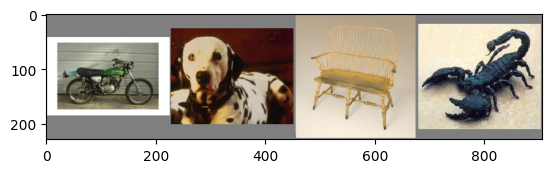

Motorbikes dalmatian  windsor_chair scorpion  


In [ ]:


# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"{images.shape = }")
print(f"{labels = }")

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:10s}' for j in range(batch_size)))

# Define a Loss function and optimizer

# Train

In [ ]:
def train(net, train_loader, criterion, optimizer, device, epochs=2):
    print_every_n_batch = (len(train_loader) / batch_size) // 10
    if print_every_n_batch == 0:
        print_every_n_batch = 1
    net.to(device)
    for epoch in range(epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(train_loader):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            # Move inputs and labels to the device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            # print(f"Inputs: {inputs.shape = }", flush=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % print_every_n_batch == 0 and i:
                print(
                    f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_every_n_batch:.3f}"
                )
                running_loss = 0.0

    print("Finished Training")


def evaluate_model(net, test_loader, device):
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in test_loader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            # calculate outputs by running images through the network
            outputs = net(images)
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total

    # Compute precision, recall, and f1-score for each class
    from sklearn.metrics import precision_recall_fscore_support

    precision, recall, f1score, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average="weighted"
    )

    print(f"Accuracy of the network on the {total} test images: {accuracy:.2f}%")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")
    print(f"Weighted F1-score: {f1score:.4f}")

    return accuracy, precision, recall, f1score

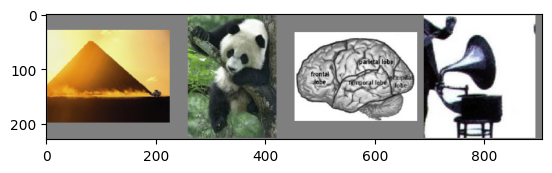

GroundTruth:
 pyramid    panda      brain      gramophone


In [ ]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print("GroundTruth:\n", " ".join(f"{classes[labels[j]]:10s}" for j in range(4)))

# Our model

In [ ]:
# https://pytorch.org/vision/stable/models.html

class EfficientNetB0(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.efficientnet_b0 = torchvision.models.efficientnet_b0(weights="DEFAULT")
        self.efficientnet_b0.classifier[1] = nn.Linear(
            self.efficientnet_b0.classifier[1].in_features, n_classes
        )

    def forward(self, x):
        return F.log_softmax(self.efficientnet_b0(x), dim=1)

efficientnet = EfficientNetB0(n_classes=len(classes))
efficientnet

EfficientNetB0(
  (efficientnet_b0): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
           

In [ ]:
criterion = nn.CrossEntropyLoss()
params_to_update_1 = []

for name, param in efficientnet.named_parameters():
    if name.startswith("efficientnet_b0.classifier"):
        param.requires_grad = True
        params_to_update_1.append(param)
    else:
        param.requires_grad = False

print(f"{len(params_to_update_1) = }")

optimizer = torch.optim.SGD(params_to_update_1, lr=1e-3)

len(params_to_update_1) = 2
len(params_to_update_2) = 0
len(params_to_update_3) = 0


In [ ]:
model_path = "./data/caltech_finetuned_efficient_net.pth"
model = efficientnet
NB_EPOCHS = 3

if True:
    train(model, train_loader, criterion, optimizer, device, epochs=NB_EPOCHS)
    torch.save(model.state_dict(), model_path)
else:
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
evaluate_model(model, test_loader, device)

[1,    44] loss: 4.691


KeyboardInterrupt: 